# Visualizar los datos

### IMPORTS

In [11]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos
import numpy as np    # librería numérica
import matplotlib.pyplot as plt  # para crear gráficos
import math as m

import ROOT
import numpy as np
import uproot


from scipy import special
from scipy.stats import norm


/home/borja/anaconda3/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/home/borja/anaconda3/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/borja/anaconda3/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [12]:
def print_mw_c(a: float = 3.0,
               b: float = 1.75e4,
               n: int   = 150,
               fmt: str = "{: .8e}",
               elems_per_line: int = 8,
               var_name: str = "mw",
               const: bool = True) -> None:
    """
    Genera el vector geométricamente espaciado con np.geomspace y lo imprime
    como un literal de array de C que puedes copiar‑y‑pegar directamente.

    Parámetros
    ----------
    a, b : float
        Extremos del rango geométrico.
    n : int
        Cantidad de puntos (valor por defecto 150).
    fmt : str
        Formato de cada número (por defecto 8 decimales en notación exponencial).
    elems_per_line : int
        Cantidad de elementos por línea (para mejorar la legibilidad).
    var_name : str
        Nombre de la variable C que se declarará.
    const : bool
        Si True se añade `const` al principio de la declaración.
    """
    # 1. Generamos el vector
    arr = np.geomspace(a, b, n)

    # 2. Construimos la línea de apertura
    const_str = "const " if const else ""
    header = f"static {const_str}double {var_name}[{n}] = {{"
    print(header)

    # 3. Imprimimos los valores, 8 por línea (puedes cambiar `elems_per_line`)
    line = "    "  # sangría de 4 espacios
    for i, val in enumerate(arr, start=1):
        line += fmt.format(val) + ", "
        if i % elems_per_line == 0:
            # terminamos la línea
            print(line.rstrip(", "))
            line = "   ,"  # reiniciamos sangría

    # Si quedó algo sin imprimir
    if line.strip():
        print(line.rstrip(", "))

    # 4. Cierre
    print("};")
    
def _fmt_val(val: float) -> str:
    """
    Devuelve la cadena de `val` con:
        * 2 decimales por defecto
        * Si el último decimal es 0 → se muestra una sola cifra decimal
        * Si ambos decimales son 0 → se muestra “.0”
    """
    s = f"{val:.2f}"          # 3.00 → "3.00", 3.10 → "3.10", 3.12 → "3.12"
    s = s.rstrip('0').rstrip('.')  # 3.00→"3", 3.10→"3.1", 3.12→"3.12"

    # Si quedó sin punto, añadimos ".0" (caso 3.00)
    if '.' not in s:
        s += ".0"
    return s

def print_hist_mw_c(mw: np.ndarray,
                    var_name: str = "hist_mw",
                    elems_per_line: int = 6,
                    const: bool = True) -> None:
    """
    Imprime en stdout una declaración C de un array de cadenas con el
    nombre `hist_mw_<valor>`.  
    Se usa la función interna `_fmt_val` para el formato solicitado.
    """
    const_str = "const " if const else ""
    n = len(mw)

    print(f"static {const_str}const char *{var_name}[{n}] = {{")
    line = "    "

    for i, v in enumerate(mw, start=1):
        txt = f"hist_mw_{_fmt_val(v)}"
        line += f'"{txt}", '
        if i % elems_per_line == 0:
            print(line.rstrip(", "))
            line = "   ,"

    if line.strip():               # resto de elementos que no llenaron la línea
        print(line.rstrip(", "))
    print("};")

# Generamos los datos del ritmo diferencial

Primero generamos una lista de masas de wimp entre 2 valores preestablecidos en escala logarítmica

In [13]:
#Numero de puntos del plot
n_masas=150

#Valor mínimo de masa
masa_min=3

#Valor máximo de masa
masa_max=1.75e04

array_masas=np.geomspace(masa_min,masa_max,n_masas)
#print(array_masas)

## Generar el archivo .root con los histogramas

Genera un histograma de 1000 bines de nombre "hist_mw_xxxxx.xx" para cada masa de Wimp con el ritmo diferencial desde 0 a 100 keV_ee y los guarda todos en un mismo archivo de root llamado 

### Genera lista con los nombres de los histogramas

In [14]:
print_hist_mw_c(array_masas)

static const const char *hist_mw[150] = {
    "hist_mw_3.0", "hist_mw_3.18", "hist_mw_3.37", "hist_mw_3.57", "hist_mw_3.79", "hist_mw_4.01"
   ,"hist_mw_4.25", "hist_mw_4.51", "hist_mw_4.78", "hist_mw_5.07", "hist_mw_5.37", "hist_mw_5.69"
   ,"hist_mw_6.03", "hist_mw_6.39", "hist_mw_6.78", "hist_mw_7.18", "hist_mw_7.61", "hist_mw_8.07"
   ,"hist_mw_8.55", "hist_mw_9.06", "hist_mw_9.61", "hist_mw_10.18", "hist_mw_10.79", "hist_mw_11.44"
   ,"hist_mw_12.13", "hist_mw_12.85", "hist_mw_13.62", "hist_mw_14.44", "hist_mw_15.3", "hist_mw_16.22"
   ,"hist_mw_17.19", "hist_mw_18.22", "hist_mw_19.32", "hist_mw_20.47", "hist_mw_21.7", "hist_mw_23.0"
   ,"hist_mw_24.38", "hist_mw_25.84", "hist_mw_27.39", "hist_mw_29.03", "hist_mw_30.77", "hist_mw_32.61"
   ,"hist_mw_34.57", "hist_mw_36.64", "hist_mw_38.83", "hist_mw_41.16", "hist_mw_43.63", "hist_mw_46.24"
   ,"hist_mw_49.01", "hist_mw_51.95", "hist_mw_55.06", "hist_mw_58.36", "hist_mw_61.86", "hist_mw_65.57"
   ,"hist_mw_69.49", "hist_mw_73.66", 

### Comprueba que se han guardado los histogramas correctamente en el archivo root

In [15]:
file = uproot.open("Results/RAPIDD_SI_TH1D.root")
#file.keys()

In [16]:

y=file["hist_mw_4864.03"].values()
x=np.arange(0,100,(100/len(y)))
print(len(x))
print(len(y))

1000
1000


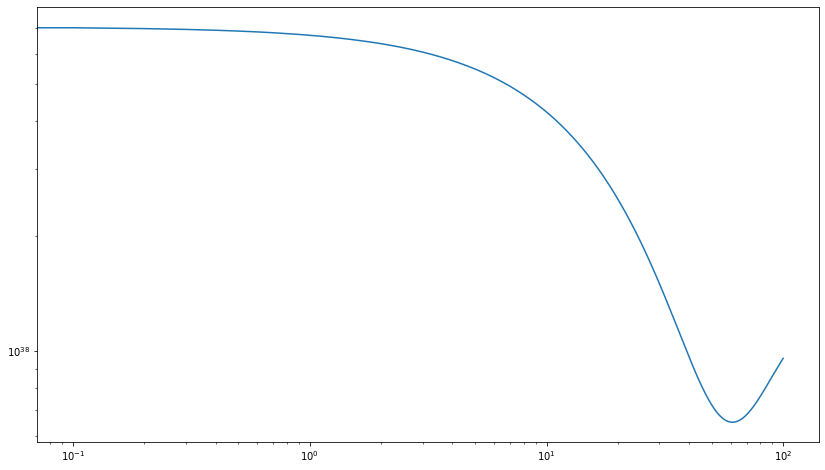

In [18]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()
ax.set_yscale("log")
ax.set_xscale("log")

plt.plot(x,y)

#print(y)